# 08 — Analyse longitudinale

## Décision d'applicabilité (A)
**APPLICABLE**

Pourquoi : les données sont un panel école-année-niveau (150 écoles × 7 années × 5 niveaux), ce qui
permet une analyse temporelle/longitudinale au **niveau école et groupe**.

Limite importante : il n'y a pas d'identifiant élève individuel, donc pas de trajectoire individuelle.
L'analyse longitudinale est donc réalisée sur des trajectoires **agrégées** (écoles, statuts, niveaux).


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_processed_dataset
from src.analysis import (
    build_school_level_panel,
    gap_over_time,
    save_table,
    yearly_trend_by_group,
    figures_output_dir,
)

FIG_DIR = figures_output_dir()
df = load_processed_dataset("education_prioritaire")
print(df.shape)


(5250, 21)


## 1. Évolution temporelle moyenne par statut

In [2]:
yearly_status = (
    df.groupby(["annee", "statut"], observed=True)["variable_cible"]
    .mean()
    .reset_index()
)
save_table(yearly_status, "08_serie_temporelle_score_par_statut")
yearly_status.head()


,annee,statut,variable_cible
0,2017,Hors EP,78.594071
1,2017,REP,71.980146
2,2017,REP+,69.778560
3,2018,Hors EP,80.660241
4,2018,REP,73.093535


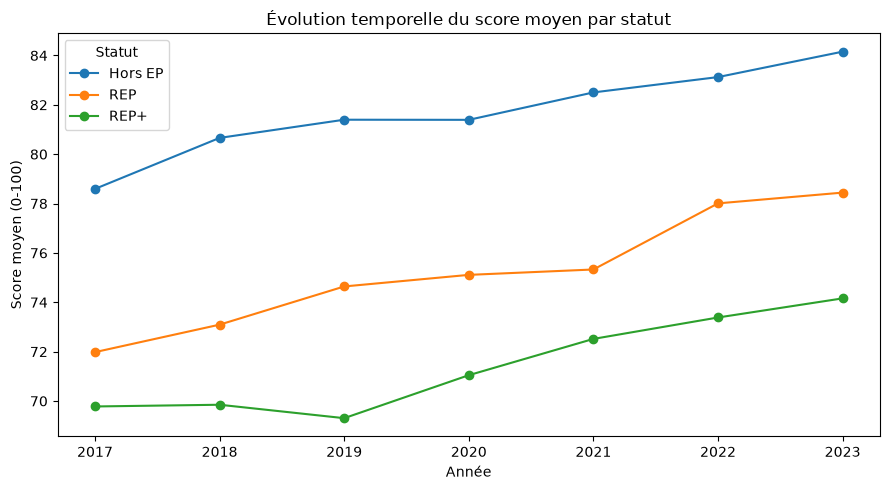

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for statut, sdf in yearly_status.groupby("statut", observed=True):
    ax.plot(sdf["annee"], sdf["variable_cible"], marker="o", label=statut)
ax.set_title("Évolution temporelle du score moyen par statut")
ax.set_xlabel("Année")
ax.set_ylabel("Score moyen (0-100)")
ax.legend(title="Statut")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_tendance_temporelle_statut.png")
plt.show()


**Interprétation.** Les trois statuts progressent globalement dans le temps, avec une hiérarchie
persistante Hors EP > REP > REP+. La progression temporelle ne supprime pas l'écart de niveau.

## 2. Tendance (pente annuelle) par statut

In [4]:
trend_status = yearly_trend_by_group(df, value_col="variable_cible", group_col="statut", time_col="annee")
save_table(trend_status, "08_tendance_lineaire_par_statut")
trend_status


,statut,n_points_temporels,pente_par_an,interception,r,r2,p_value_pente,erreur_standard_pente,moyenne_debut,moyenne_fin,delta_debut_fin
0,REP,7,1.068081,-2082.294845,0.975899,0.952379,0.000171,0.106811,71.980146,78.443744,6.463597
1,REP+,7,0.836478,-1618.250856,0.936592,0.877204,0.001879,0.139962,69.778560,74.158231,4.379671
2,Hors EP,7,0.811284,-1557.103361,0.969358,0.939656,0.000311,0.091943,78.594071,84.154565,5.560493


**Interprétation.** Les pentes annuelles sont positives pour les trois groupes (amélioration moyenne),
mais l'écart de niveau initial reste substantiel, ce qui traduit une progression parallèle plus qu'une
convergence forte.

## 3. Stabilité des écarts dans le temps (REP+ vs Hors EP)

In [5]:
gap_repplus_horsep = gap_over_time(
    df,
    value_col="variable_cible",
    time_col="annee",
    group_col="statut",
    group_ref="Hors EP",
    group_compare="REP+",
)
save_table(gap_repplus_horsep, "08_ecart_repplus_vs_horsep_temps")
gap_repplus_horsep


statut,annee,Hors EP,REP+,ecart_compare_moins_ref
0,2017,78.594071,69.778560,-8.815511
1,2018,80.660241,69.848500,-10.811741
2,2019,81.397079,69.304476,-12.092602
3,2020,81.392107,71.046138,-10.345969
4,2021,82.502929,72.516182,-9.986747
5,2022,83.124545,73.383826,-9.740719
6,2023,84.154565,74.158231,-9.996334


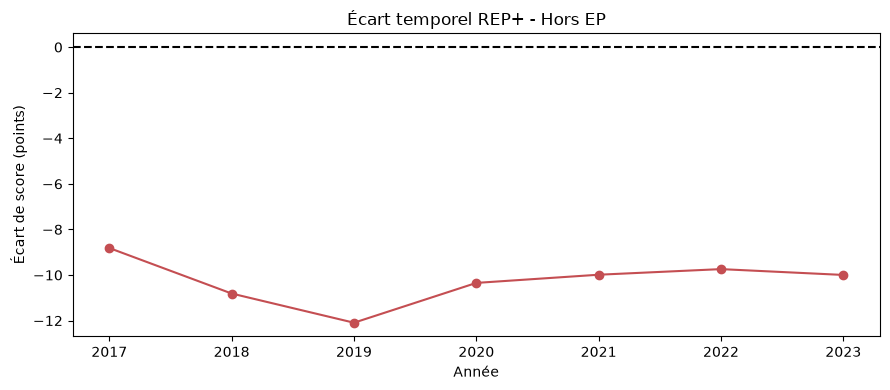

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gap_repplus_horsep["annee"], gap_repplus_horsep["ecart_compare_moins_ref"], marker="o", color="#C44E52")
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Écart temporel REP+ - Hors EP")
ax.set_xlabel("Année")
ax.set_ylabel("Écart de score (points)")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_ecart_repplus_horsep_temps.png")
plt.show()


**Interprétation.** L'écart reste négatif sur toute la période (REP+ en dessous de Hors EP). Sa
valeur fluctue selon les années mais ne converge pas vers zéro, indiquant une persistance des inégalités.

## 4. Trajectoires des écoles (niveau agrégé école-année)

In [7]:
school_panel = build_school_level_panel(df)
save_table(school_panel, "08_panel_ecole_annee")
school_panel.head()


,ecole_id,annee,score_moyen,ips_moyen,taille_moyenne_classe,part_dedoublement,rep,rep_plus,statut_mode
0,1,2017,69.370,44.69,18.73,0.0,1.0,0.0,REP
1,1,2018,82.702,63.15,16.73,0.0,0.0,0.0,Hors EP
2,1,2019,70.884,93.12,12.00,1.0,0.0,1.0,REP+
3,1,2020,69.906,67.87,14.78,1.0,0.0,1.0,REP+
4,1,2021,75.642,77.12,18.50,0.0,1.0,0.0,REP


In [8]:
school_delta = (
    school_panel.pivot(index="ecole_id", columns="annee", values="score_moyen")
)
school_delta["delta_2017_2023"] = school_delta[2023] - school_delta[2017]
delta_summary = school_delta["delta_2017_2023"].describe().to_frame(name="valeur")
save_table(delta_summary, "08_distribution_delta_ecoles_2017_2023")
delta_summary


,valeur
count,150.00000
mean,5.62004
std,7.34379
min,-16.79800
25%,0.81350
50%,5.50000
75%,10.52650
max,25.03200


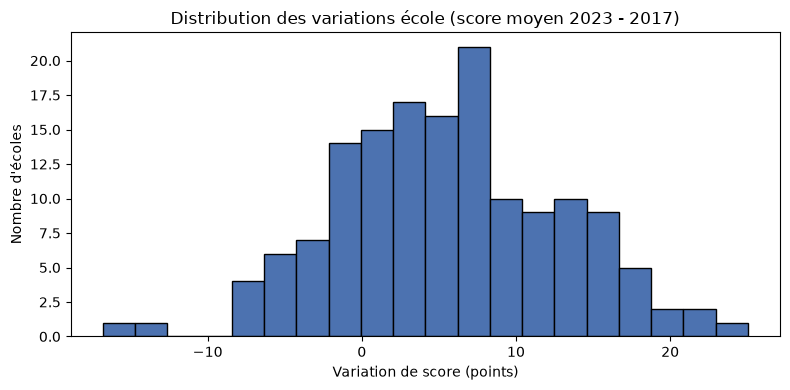

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(school_delta["delta_2017_2023"], bins=20, edgecolor="black", color="#4C72B0")
ax.set_title("Distribution des variations école (score moyen 2023 - 2017)")
ax.set_xlabel("Variation de score (points)")
ax.set_ylabel("Nombre d'écoles")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_distribution_delta_ecoles.png")
plt.show()


**Interprétation.** Les trajectoires école montrent une hétérogénéité réelle : certaines écoles
gagnent nettement des points, d'autres stagnent voire reculent. Cela justifie des analyses ciblées par
profil (cf. notebook 07) plutôt qu'une lecture uniquement moyenne.

## 5. Hypothèses, limites et portée de l'analyse longitudinale

### Hypothèses utilisées
- comparabilité minimale des mesures de score entre années ;
- structure de panel stable au niveau école (mêmes `ecole_id` observées) ;
- interprétation en tendance agrégée (et non en causalité).

### Limites
- pas d'identifiant élève : impossible d'estimer de vraies trajectoires individuelles ;
- données simulées/reconstruites : résultats numériques non transposables tels quels à la population réelle ;
- changements de statut école dans le temps fréquents, complexifiant l'interprétation institutionnelle.

### Portée
Cette étape répond à la question d'évolution temporelle et de stabilité des écarts, mais ne permet pas
à elle seule une conclusion causale sur l'effet du dédoublement.
